# Kanban Reorder-Point Optimisation
**Data-driven review of Kanban reorder points for an aerospace composite-parts manufacturing site**

*Author: Anoop Channaiah · Master of Business Analytics, Deakin University*

## Business problem
A composite-parts manufacturer runs a two-bin / multi-card **Kanban** system for 120 production
consumables and raw materials (carbon-fibre prepreg, resins, fasteners, honeycomb core, bagging
consumables…). The reorder point (ROP) for each part was set by buyer judgement when the part
was introduced — *quoted lead time + a 1–6 week buffer × first-year average demand* — and rarely
reviewed since. Production rate has since increased and supplier lead times have proven variable.

**Questions**
1. Which parts matter most (value and demand behaviour)?
2. How well do the legacy Kanban settings actually protect production?
3. What should the reorder points be, and what does that cost in inventory?
4. Where is the biggest lever — our settings, or supplier lead-time reliability?

> **Data note:** the dataset is **simulated** (see `src/generate_data.py`) to mimic real
> production-consumable behaviour. No company data is used. The methods transfer directly to an
> ERP/MRP extract of weekly consumption, part master and goods-receipt history.

## Approach
| Step | Method |
|---|---|
| Segment | ABC (consumption value) × XYZ (demand variability) + Syntetos-Boylan demand classes |
| Forecast | Per-part model selection (moving averages, exponential smoothing, Croston-SBA) with rolling-origin validation |
| Size | Safety stock covering **both** demand and lead-time uncertainty; ROP; number of Kanban cards |
| Test | Monte-Carlo simulation of the Kanban loop on **out-of-sample** demand (weeks 79–104), 100 runs per part per policy |
| Decide | Service-level vs inventory trade-off curve; lead-time variability scenario |

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from inventory import (abc_class, xyz_class, sbc_class, METHODS, rolling_origin_errors,
                       safety_stock, z_for, simulate_kanban)
import style
style.apply()
warnings.filterwarnings("ignore")
IMG = ROOT / "images"; IMG.mkdir(exist_ok=True)
pd.set_option("display.float_format", "{:,.2f}".format)

parts = pd.read_csv(ROOT / "data/parts_master.csv").set_index("part_number")
demand = pd.read_csv(ROOT / "data/weekly_demand.csv").pivot(index="week", columns="part_number", values="qty")
receipts = pd.read_csv(ROOT / "data/receipts_log.csv")
print(f"{len(parts)} parts · {demand.shape[0]} weeks of demand · {len(receipts):,} historical receipts")
parts.head()

120 parts · 104 weeks of demand · 1,974 historical receipts


,category,supplier_id,unit_cost_aud,demand_pattern,lead_time_mean_wks,lead_time_sd_wks,kanban_container_qty,legacy_reorder_point
part_number,,,,,,,,
PN-10001,Sealants & paint,SUP-008,73.93,smooth,4.66,0.43,48,434
PN-10002,Fasteners,SUP-014,0.79,erratic,3.85,1.27,280,1856
PN-10003,Tooling & cutting,SUP-003,38.08,smooth,5.83,1.23,28,264
PN-10004,Vacuum bagging consumables,SUP-004,8.05,intermittent,3.72,0.77,200,2059
PN-10005,Carbon fibre prepreg,SUP-022,306.92,smooth,6.13,1.86,26,154


### Train / validation / test split
* **Weeks 1–52**: fit forecasts · **Weeks 53–78**: validate & choose method per part (and simulation warm-up)
* **Weeks 79–104**: held-out test period — policies are judged only on demand they never saw.

In [2]:
TRAIN_END, VALID_START = 78, 52
train = demand.loc[:TRAIN_END]
last52 = train.iloc[-52:]

## 1. Segmentation — ABC × XYZ

In [3]:
parts["annual_qty"] = last52.sum()
parts["annual_value"] = parts.annual_qty * parts.unit_cost_aud
parts["abc"] = abc_class(parts.annual_value)
parts["cv"] = train.std() / train.mean()
parts["xyz"] = xyz_class(parts.cv)
adi = train.apply(lambda s: len(s) / max((s > 0).sum(), 1))
nz_cv2 = train.apply(lambda s: (s[s > 0].std() / s[s > 0].mean()) ** 2)
parts["demand_class"] = [sbc_class(a, c) for a, c in zip(adi, nz_cv2)]

seg_n = pd.crosstab(parts.abc, parts.xyz)
seg_v = pd.crosstab(parts.abc, parts.xyz, values=parts.annual_value, aggfunc="sum").fillna(0)
seg_share = seg_v / seg_v.values.sum()
abc_summary = parts.groupby("abc").agg(parts=("annual_value", "size"), value=("annual_value", "sum"))
abc_summary["share_of_parts"] = abc_summary.parts / len(parts)
abc_summary["share_of_value"] = abc_summary.value / abc_summary.value.sum()
display(abc_summary)
display(parts.demand_class.value_counts().rename("parts"))

,parts,value,share_of_parts,share_of_value
abc,,,,
A,45,"22,775,635.86",0.38,0.79
B,34,"4,433,481.06",0.28,0.15
C,41,"1,486,477.76",0.34,0.05


demand_class
Smooth          66
Erratic         33
Intermittent    11
Lumpy           10
Name: parts, dtype: int64

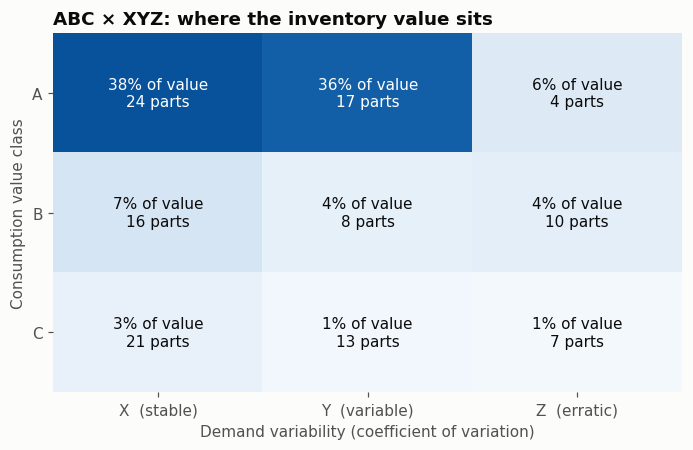

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.imshow(seg_share.values, cmap="Blues", aspect="auto", vmin=0, vmax=seg_share.values.max() * 1.15)
for i in range(3):
    for j in range(3):
        v, n = seg_share.values[i, j], seg_n.values[i, j]
        ax.text(j, i, f"{v:.0%} of value\n{n} parts", ha="center", va="center", fontsize=10,
                color="white" if v > seg_share.values.max() * 0.55 else style.INK)
ax.set_xticks(range(3), ["X  (stable)", "Y  (variable)", "Z  (erratic)"])
ax.set_yticks(range(3), ["A", "B", "C"])
ax.grid(False)
ax.set_title("ABC × XYZ: where the inventory value sits")
ax.set_xlabel("Demand variability (coefficient of variation)")
ax.set_ylabel("Consumption value class")
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.savefig(IMG / "01_abc_xyz_matrix.png"); plt.show()

## 2. Forecasting — pick the best method per part
Each method produces rolling one-step-ahead forecasts over weeks 53–78. The method with the lowest
RMSE is chosen per part (MAE is avoided because it rewards forecasting zero on intermittent parts); its RMSE becomes the demand-uncertainty input (σ) for safety stock —
this is better than using the raw standard deviation, because it measures the error we
will actually live with.

In [5]:
choice, sigma, mae_tbl = {}, {}, []
for pn in parts.index:
    y = train[pn].values.astype(float)
    errs = {m: rolling_origin_errors(y, VALID_START, m) for m in METHODS}
    mae = {m: np.mean(np.abs(e)) for m, e in errs.items()}
    rmse = {m: np.sqrt(np.mean(e ** 2)) for m, e in errs.items()}
    best = min(rmse, key=rmse.get)  # RMSE, not MAE: MAE rewards forecasting zero on intermittent parts
    choice[pn], sigma[pn] = best, float(np.sqrt(np.mean(errs[best] ** 2)))
    mae_tbl.append({"part_number": pn, **mae})
parts["forecast_method"] = pd.Series(choice)
parts["sigma_weekly"] = pd.Series(sigma)
parts["forecast_weekly"] = [METHODS[parts.at[pn, "forecast_method"]](train[pn].values.astype(float))
                            for pn in parts.index]

mae_tbl = pd.DataFrame(mae_tbl).set_index("part_number")
wape_best = sum(mae_tbl.loc[pn, choice[pn]] for pn in parts.index) / sum(train.loc[VALID_START + 1:, pn].mean() for pn in parts.index)
wape_ma13 = mae_tbl["MA-13"].sum() / sum(train.loc[VALID_START + 1:, pn].mean() for pn in parts.index)
print(f"Validation WAPE — single method for all parts (MA-13): {wape_ma13:.1%}   per-part best method: {wape_best:.1%}")
display(pd.crosstab(parts.demand_class, parts.forecast_method))

Validation WAPE — single method for all parts (MA-13): 54.8%   per-part best method: 51.7%


forecast_method,Croston-SBA,MA-13,MA-26,MA-4,SES a=0.1,SES a=0.3
demand_class,,,,,,
Erratic,6,5,18,1,2,1
Intermittent,2,1,6,1,0,1
Lumpy,7,0,2,1,0,0
Smooth,2,7,39,3,12,3


## 3. Lead-time performance from goods-receipt history

In [6]:
lt = (receipts[receipts.order_week <= TRAIN_END]
      .groupby("part_number").actual_lead_time_wks.agg(lt_mean="mean", lt_sd="std", receipts="size"))
parts = parts.join(lt)
parts["lt_cv"] = parts.lt_sd / parts.lt_mean
display(parts.groupby("category")[["lt_mean", "lt_sd", "lt_cv"]].mean().sort_values("lt_mean", ascending=False))

,lt_mean,lt_sd,lt_cv
category,,,
Carbon fibre prepreg,9.57,2.38,0.25
Honeycomb core,9.52,1.59,0.17
Resin & adhesives,6.42,1.36,0.21
Fasteners,5.05,1.06,0.22
Sealants & paint,4.84,0.87,0.18
Tooling & cutting,4.49,0.98,0.22
Vacuum bagging consumables,3.41,0.70,0.20
PPE & shop consumables,1.76,0.36,0.18


## 4. Recommended reorder points
$$SS = z\sqrt{LT\cdot\sigma_d^2 + \bar d^2\cdot\sigma_{LT}^2}\qquad ROP = \bar d\cdot LT + SS\qquad \text{Kanban cards} = \lceil ROP / Q \rceil + 1$$

Service targets are differentiated by ABC class: expensive **A** parts get a slightly lower target
(every extra unit is costly), cheap **C** parts a higher one (a stock-out of a $2 consumable
must never stop the line).

In [7]:
SERVICE = {"A": 0.95, "B": 0.97, "C": 0.99}

def recommend(p, service=SERVICE, lt_sd_factor=1.0):
    z = z_for(service[p.abc])
    ss = safety_stock(z, p.forecast_weekly, p.sigma_weekly, p.lt_mean, p.lt_sd * lt_sd_factor)
    return int(np.ceil(p.forecast_weekly * p.lt_mean + ss)), ss

rec = parts.apply(lambda p: pd.Series(recommend(p), index=["recommended_rop", "safety_stock"]), axis=1)
parts = parts.join(rec)
parts["recommended_rop"] = parts.recommended_rop.astype(int)
parts["kanban_cards"] = np.ceil(parts.recommended_rop / parts.kanban_container_qty).astype(int) + 1
avg_wk = train.iloc[-26:].mean()
parts["legacy_cover_wks"] = parts.legacy_reorder_point / avg_wk
parts["recommended_cover_wks"] = parts.recommended_rop / avg_wk
parts["rop_change_pct"] = parts.recommended_rop / parts.legacy_reorder_point - 1

# share of safety stock that exists only because of lead-time variability
ss_demand_only = parts.apply(lambda p: safety_stock(z_for(SERVICE[p.abc]), p.forecast_weekly, p.sigma_weekly, p.lt_mean, 0), axis=1)
parts["ss_value"] = parts.safety_stock * parts.unit_cost_aud
parts["ss_value_lt_driven"] = (parts.safety_stock - ss_demand_only) * parts.unit_cost_aud
lt_share = parts.ss_value_lt_driven.sum() / parts.ss_value.sum()
print(f"Share of safety-stock value driven by supplier lead-time variability: {lt_share:.0%}")

direction = pd.cut(parts.rop_change_pct, [-np.inf, -0.10, 0.10, np.inf],
                   labels=["Reduce ROP (>10% lower)", "Keep (±10%)", "Increase ROP (>10% higher)"])
display(direction.value_counts().rename("parts"))

Share of safety-stock value driven by supplier lead-time variability: 32%


rop_change_pct
Increase ROP (>10% higher)    55
Reduce ROP (>10% lower)       41
Keep (±10%)                   24
Name: parts, dtype: int64

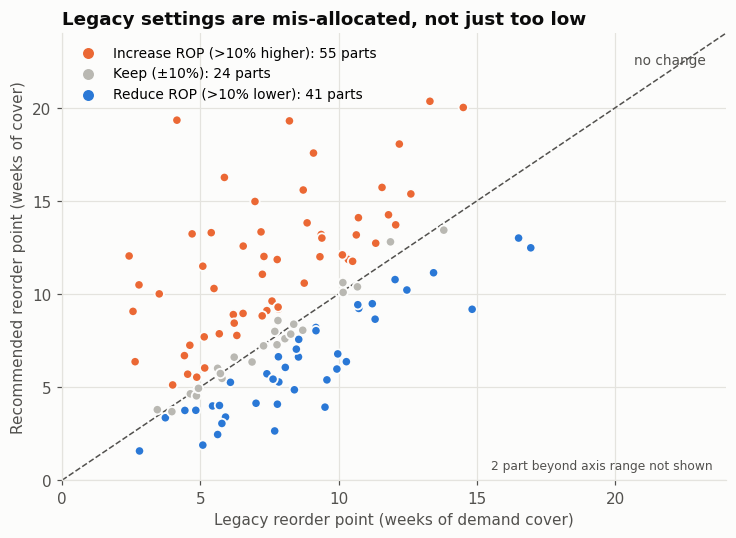

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 5))
colors = direction.map({"Reduce ROP (>10% lower)": style.BLUE, "Keep (±10%)": "#b9b8b2",
                        "Increase ROP (>10% higher)": style.ORANGE})
ax.scatter(parts.legacy_cover_wks, parts.recommended_cover_wks, s=38, c=colors,
           edgecolor=style.SURFACE, linewidth=1.2, zorder=3)
lim = 24  # a single outlier (>30 wks legacy cover) is clipped to keep the cloud readable
n_out = int(((parts.legacy_cover_wks > lim) | (parts.recommended_cover_wks > lim)).sum())
ax.plot([0, lim], [0, lim], color=style.INK2, lw=1, ls="--", zorder=2)
ax.text(lim * 0.97, lim * 0.93, "no change", ha="right", color=style.INK2, fontsize=9)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Legacy reorder point (weeks of demand cover)")
ax.set_ylabel("Recommended reorder point (weeks of cover)")
ax.set_title("Legacy settings are mis-allocated, not just too low")
for lab, c in [("Increase ROP (>10% higher)", style.ORANGE), ("Keep (±10%)", "#b9b8b2"), ("Reduce ROP (>10% lower)", style.BLUE)]:
    ax.scatter([], [], c=c, s=38, label=f"{lab}: {(direction == lab).sum()} parts")
ax.legend(loc="upper left", fontsize=9)
if n_out:
    ax.text(lim * 0.98, 0.6, f"{n_out} part beyond axis range not shown", ha="right", fontsize=8, color=style.INK2)
plt.tight_layout(); plt.savefig(IMG / "02_legacy_vs_recommended_cover.png"); plt.show()

## 5. Monte-Carlo test on held-out demand
The Kanban loop is simulated week by week: receive → consume (shortfalls are back-ordered, i.e.
the line waits) → release a card for each container when inventory position ≤ ROP.
Supplier lead times are random each order. Both policies face **identical** demand
(weeks 53–78 warm-up, KPIs measured on test weeks 79–104) and container sizes; only the ROP differs.

In [9]:
N_RUNS = 100
sim_demand = demand.loc[VALID_START + 1:]
MEASURE_FROM = TRAIN_END - VALID_START  # index of week 79 within sim_demand

def run_policy(rops, n_runs, seed, lt_sd_factor=1.0, keep_trace=None):
    rng = np.random.default_rng(seed)
    out, trace = [], {}
    for pn in parts.index:
        p = parts.loc[pn]; d = sim_demand[pn].values
        kp = []
        for r in range(n_runs):
            k = simulate_kanban(d, rops[pn], p.kanban_container_qty, p.lead_time_mean_wks,
                                p.lead_time_sd_wks * lt_sd_factor, rng, measure_from=MEASURE_FROM)
            kp.append(k)
            if keep_trace == pn and r == 0:
                trace = k["trace"]
        out.append(dict(part_number=pn, fill_rate=np.mean([k["fill_rate"] for k in kp]),
                        stockout_weeks=np.mean([k["stockout_weeks"] for k in kp]),
                        avg_inventory_aud=np.mean([k["avg_on_hand"] for k in kp]) * p.unit_cost_aud,
                        orders=np.mean([k["orders"] for k in kp]),
                        test_demand=d[MEASURE_FROM:].sum()))
    return pd.DataFrame(out).set_index("part_number"), trace

def kpis(df):
    return pd.Series({
        "Fill rate (volume-weighted)": (df.fill_rate * df.test_demand).sum() / df.test_demand.sum(),
        "Parts below 95% fill": int((df.fill_rate < 0.95).sum()),
        "Stock-out weeks (26 wks, all parts)": df.stockout_weeks.sum(),
        "Average inventory (AUD)": df.avg_inventory_aud.sum(),
    })

EXAMPLE = parts[parts.abc == "A"].sort_values("lt_sd", ascending=False).index[0]
# Option A — budget-neutral rebalance: lower service targets chosen so total inventory stays
# roughly where it is today; the gain comes purely from putting stock on the right parts.
BUDGET_NEUTRAL = {"A": 0.85, "B": 0.92, "C": 0.97}
parts["rebalanced_rop"] = parts.apply(lambda p: recommend(p, BUDGET_NEUTRAL)[0], axis=1)

legacy, tr_legacy = run_policy(parts.legacy_reorder_point, N_RUNS, seed=1, keep_trace=EXAMPLE)
rebal, _ = run_policy(parts.rebalanced_rop, N_RUNS, seed=1)
optim, tr_optim = run_policy(parts.recommended_rop, N_RUNS, seed=1, keep_trace=EXAMPLE)
results = pd.DataFrame({"Legacy Kanban": kpis(legacy),
                        "Option A: budget-neutral rebalance": kpis(rebal),
                        "Option B: high-service (recommended)": kpis(optim)})
display(results.style.format("{:,.3f}", subset=pd.IndexSlice[["Fill rate (volume-weighted)"], :])
        .format("{:,.0f}", subset=pd.IndexSlice[["Parts below 95% fill", "Stock-out weeks (26 wks, all parts)", "Average inventory (AUD)"], :]))
L, A_, O = results.iloc[:, 0], results.iloc[:, 1], results.iloc[:, 2]

,Legacy Kanban,Option A: budget-neutral rebalance,Option B: high-service (recommended)
Fill rate (volume-weighted),0.944,0.950,0.980
Parts below 95% fill,38,28,10
"Stock-out weeks (26 wks, all parts)",294,187,74
Average inventory (AUD),"1,731,584","1,783,469","2,482,092"


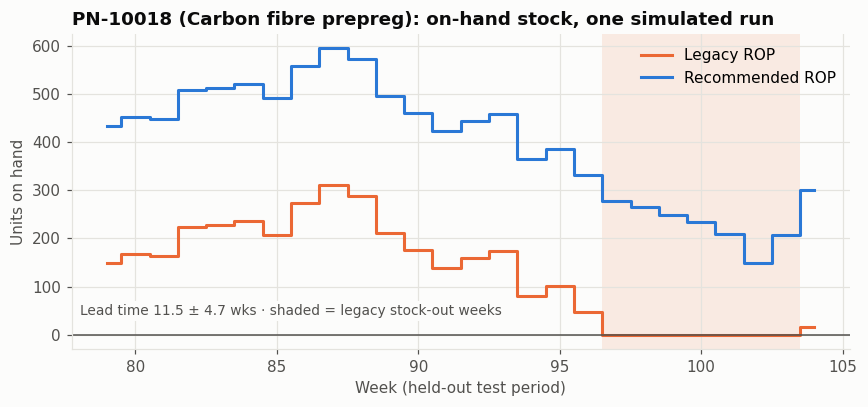

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.8))
wk = np.arange(TRAIN_END + 1, TRAIN_END + 1 + len(tr_legacy))
ax.step(wk, tr_legacy, where="mid", color=style.ORANGE, label="Legacy ROP")
ax.step(wk, tr_optim, where="mid", color=style.BLUE, label="Recommended ROP")
so = wk[np.asarray(tr_legacy) <= 0]
for w in so:
    ax.axvspan(w - 0.5, w + 0.5, color=style.ORANGE, alpha=0.12, lw=0)
ax.axhline(0, color=style.INK2, lw=1)
ax.set_xlabel("Week (held-out test period)"); ax.set_ylabel("Units on hand")
p = parts.loc[EXAMPLE]
ax.set_title(f"{EXAMPLE} ({p.category}): on-hand stock, one simulated run")
ax.text(0.01, 0.10, f"Lead time {p.lt_mean:.1f} ± {p.lt_sd:.1f} wks · shaded = legacy stock-out weeks",
        transform=ax.transAxes, va="bottom", fontsize=9, color=style.INK2,
        bbox=dict(facecolor=style.SURFACE, edgecolor="none", pad=2))
ax.legend(loc="upper right")
plt.tight_layout(); plt.savefig(IMG / "03_example_part_simulation.png"); plt.show()

## 6. The trade-off: service level vs inventory investment
A single "right" ROP does not exist — it depends on how much line-stoppage risk the business
will accept. The curve below re-runs the simulation across service targets, and repeats it for a
**supplier-improvement scenario** where lead-time variability is halved (e.g. through supplier
scorecards, schedule-sharing or dual-sourcing on the worst offenders).

In [11]:
GRID = [{"A": .80, "B": .85, "C": .90}, {"A": .85, "B": .90, "C": .95}, {"A": .90, "B": .93, "C": .97},
        {"A": .92, "B": .95, "C": .98}, {"A": .95, "B": .97, "C": .99}, {"A": .97, "B": .98, "C": .995},
        {"A": .99, "B": .995, "C": .998}]
frontier = []
for scen, f in [("Current supplier lead-time variability", 1.0), ("Lead-time variability halved", 0.5)]:
    for sl in GRID:
        rops = parts.apply(lambda p: recommend(p, sl, f)[0], axis=1)
        df, _ = run_policy(rops, 30, seed=3, lt_sd_factor=f)
        k = kpis(df)
        frontier.append(dict(scenario=scen, A=sl["A"], fill=k.iloc[0], inventory=k.iloc[3]))
frontier = pd.DataFrame(frontier)
display(frontier)

,scenario,A,fill,inventory
0,Current supplier lead-time variability,0.80,0.92,"1,502,368.88"
1,Current supplier lead-time variability,0.85,0.94,"1,745,637.59"
2,Current supplier lead-time variability,0.90,0.96,"2,025,240.99"
3,Current supplier lead-time variability,0.92,0.97,"2,185,662.21"
4,Current supplier lead-time variability,0.95,0.98,"2,482,951.82"
5,Current supplier lead-time variability,0.97,0.98,"2,764,683.68"
6,Current supplier lead-time variability,0.99,0.99,"3,337,945.99"
7,Lead-time variability halved,0.80,0.90,"1,286,656.57"
8,Lead-time variability halved,0.85,0.92,"1,471,308.05"
9,Lead-time variability halved,0.90,0.94,"1,679,414.80"


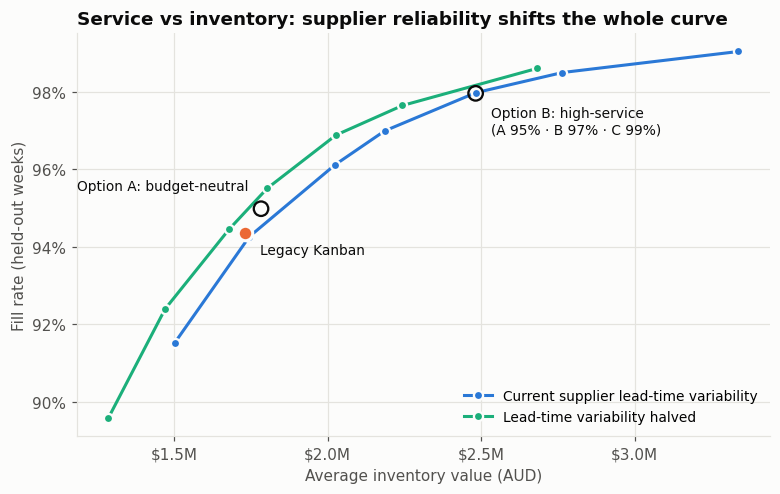

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for (scen, g), c in zip(frontier.groupby("scenario", sort=False), [style.BLUE, style.AQUA]):
    ax.plot(g.inventory / 1e6, g.fill, color=c, marker="o", ms=6, mec=style.SURFACE, mew=1.5, label=scen)
ax.scatter(L.iloc[3] / 1e6, L.iloc[0], s=90, color=style.ORANGE, zorder=5, edgecolor=style.SURFACE, linewidth=2)
ax.annotate("Legacy Kanban", (L.iloc[3] / 1e6, L.iloc[0]), xytext=(10, -14), textcoords="offset points", color=style.INK, fontsize=9)
ax.scatter(O.iloc[3] / 1e6, O.iloc[0], s=90, facecolor="none", edgecolor=style.INK, linewidth=1.5, zorder=6)
ax.annotate("Option B: high-service\n(A 95% · B 97% · C 99%)", (O.iloc[3] / 1e6, O.iloc[0]), xytext=(10, -26), textcoords="offset points", color=style.INK, fontsize=9)
ax.scatter(A_.iloc[3] / 1e6, A_.iloc[0], s=90, facecolor="none", edgecolor=style.INK, linewidth=1.5, zorder=6)
ax.annotate("Option A: budget-neutral", (A_.iloc[3] / 1e6, A_.iloc[0]), xytext=(-8, 12), textcoords="offset points", ha="right", color=style.INK, fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("$%.1fM"))
ax.set_xlabel("Average inventory value (AUD)"); ax.set_ylabel("Fill rate (held-out weeks)")
ax.set_title("Service vs inventory: supplier reliability shifts the whole curve")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig(IMG / "04_service_inventory_tradeoff.png"); plt.show()

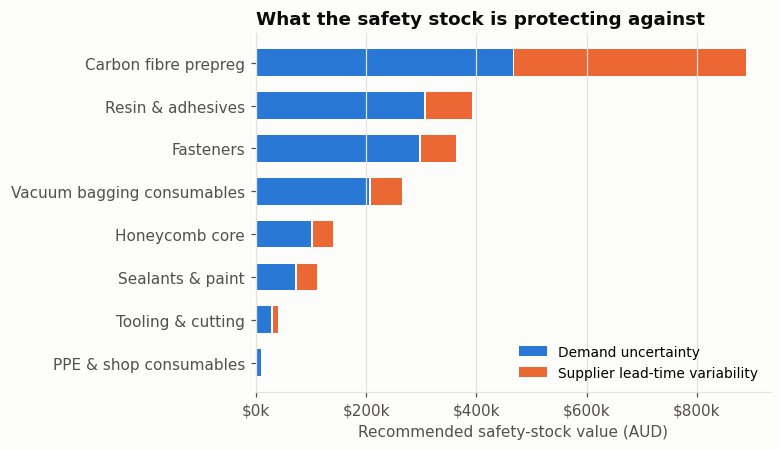

In [13]:
cat = parts.groupby("category").agg(ss_value=("ss_value", "sum"), lt_driven=("ss_value_lt_driven", "sum")).sort_values("ss_value")
cat["demand_driven"] = cat.ss_value - cat.lt_driven
fig, ax = plt.subplots(figsize=(7.2, 4.2))
y = np.arange(len(cat))
ax.barh(y, cat.demand_driven / 1e3, color=style.BLUE, height=0.62, label="Demand uncertainty")
ax.barh(y, cat.lt_driven / 1e3, left=cat.demand_driven / 1e3 + cat.ss_value.max() / 1e3 * 0.004,
        color=style.ORANGE, height=0.62, label="Supplier lead-time variability")
ax.set_yticks(y, cat.index); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("$%.0fk"))
ax.set_xlabel("Recommended safety-stock value (AUD)")
ax.set_title("What the safety stock is protecting against")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig(IMG / "05_safety_stock_drivers.png"); plt.show()

## 7. Output for the buyers — recommended Kanban settings

In [14]:
out = parts.reset_index()[["part_number", "category", "supplier_id", "abc", "xyz", "demand_class",
                           "forecast_method", "forecast_weekly", "lt_mean", "lt_sd",
                           "legacy_reorder_point", "rebalanced_rop", "recommended_rop", "rop_change_pct",
                           "kanban_container_qty", "kanban_cards"]]
out = out.join(legacy[["fill_rate"]].rename(columns={"fill_rate": "sim_fill_legacy"}), on="part_number")
out = out.join(optim[["fill_rate"]].rename(columns={"fill_rate": "sim_fill_recommended"}), on="part_number")
out = out.sort_values("rop_change_pct", key=abs, ascending=False).round(3)
out.to_csv(ROOT / "data/recommended_kanban_settings.csv", index=False)
out.head(10)

,part_number,category,supplier_id,abc,xyz,demand_class,forecast_method,forecast_weekly,lt_mean,lt_sd,legacy_reorder_point,rebalanced_rop,recommended_rop,rop_change_pct,kanban_container_qty,kanban_cards,sim_fill_legacy,sim_fill_recommended
41,PN-10042,Tooling & cutting,SUP-029,B,Z,Lumpy,MA-26,11.96,4.69,0.37,29,122,144,3.97,7,22,0.22,1.00
14,PN-10015,Fasteners,SUP-018,C,Z,Intermittent,MA-26,402.96,7.43,1.22,1673,6871,7789,3.66,210,39,0.85,1.00
31,PN-10032,PPE & shop consumables,SUP-020,C,Z,Lumpy,Croston-SBA,267.32,3.30,0.98,993,3196,3744,2.77,200,20,0.77,1.00
113,PN-10114,Vacuum bagging consumables,SUP-009,B,Z,Intermittent,MA-26,676.46,3.39,0.59,1735,5160,6131,2.53,590,12,0.34,0.99
39,PN-10040,Vacuum bagging consumables,SUP-013,C,Z,Lumpy,Croston-SBA,115.03,3.29,0.65,405,1005,1153,1.85,140,10,0.70,1.00
78,PN-10079,Vacuum bagging consumables,SUP-003,C,Z,Lumpy,MA-4,597.25,4.83,1.18,2385,5976,6709,1.81,160,43,0.51,1.00
87,PN-10088,Honeycomb core,SUP-014,A,Y,Erratic,MA-13,35.62,9.03,0.99,165,407,457,1.77,26,19,0.47,1.00
72,PN-10073,Tooling & cutting,SUP-023,C,Z,Intermittent,Croston-SBA,4.89,4.21,0.89,28,60,69,1.46,6,13,0.57,1.00
53,PN-10054,Vacuum bagging consumables,SUP-024,B,Z,Intermittent,SES a=0.3,20.39,2.66,0.35,885,1606,2132,1.41,350,8,0.49,0.85
61,PN-10062,Honeycomb core,SUP-013,B,Z,Lumpy,Croston-SBA,4.65,10.32,1.81,49,98,115,1.35,3,40,0.30,0.96


## 8. Headline results

In [15]:
f_now = frontier[frontier.scenario.str.startswith("Current")]
f_half = frontier[frontier.scenario.str.startswith("Lead")]
# inventory needed for the recommended fill rate with halved lead-time variability (interpolated)
fh, fn = f_half.sort_values("fill"), f_now.sort_values("fill")
# compare the two curves at the same fill rate (95% and 97%)
inv_at = lambda f, curve: float(np.interp(f, curve.fill, curve.inventory))
saving_95 = 1 - inv_at(0.95, fh) / inv_at(0.95, fn)
saving_97 = 1 - inv_at(0.97, fh) / inv_at(0.97, fn)
top_lt = (parts.groupby("supplier_id").ss_value_lt_driven.sum().sort_values(ascending=False))
top5_share = top_lt.head(5).sum() / parts.ss_value_lt_driven.sum()
summary = {
    "fill_legacy": L.iloc[0], "fill_rebalanced": A_.iloc[0], "fill_rec": O.iloc[0],
    "stockout_weeks_rebalanced": A_.iloc[2], "stockout_reduction_rebalanced": 1 - A_.iloc[2] / L.iloc[2],
    "parts_below95_rebalanced": int(A_.iloc[1]), "inv_rebalanced": A_.iloc[3], "inv_change_rebalanced": A_.iloc[3] / L.iloc[3] - 1,
    "stockout_weeks_legacy": L.iloc[2], "stockout_weeks_rec": O.iloc[2],
    "stockout_reduction": 1 - O.iloc[2] / L.iloc[2],
    "parts_below95_legacy": int(L.iloc[1]), "parts_below95_rec": int(O.iloc[1]),
    "inv_legacy": L.iloc[3], "inv_rec": O.iloc[3], "inv_change": O.iloc[3] / L.iloc[3] - 1,
    "inv_at_97_now": inv_at(0.97, fn), "inv_at_97_lt_halved": inv_at(0.97, fh),
    "inv_saving_lt_halved_at_95": saving_95, "inv_saving_lt_halved_at_97": saving_97,
    "lt_share_of_ss": lt_share, "top5_suppliers_share_of_lt_ss": top5_share,
    "n_reduce": int((direction == "Reduce ROP (>10% lower)").sum()),
    "n_increase": int((direction == "Increase ROP (>10% higher)").sum()),
    "wape_single": wape_ma13, "wape_best": wape_best,
}
pd.Series(summary).to_json(ROOT / "data/headline_results.json", indent=2)
for k, v in summary.items():
    print(f"{k:32s} {v:,.3f}")

fill_legacy                      0.944
fill_rebalanced                  0.950
fill_rec                         0.980
stockout_weeks_rebalanced        187.160
stockout_reduction_rebalanced    0.363
parts_below95_rebalanced         28.000
inv_rebalanced                   1,783,468.625
inv_change_rebalanced            0.030
stockout_weeks_legacy            293.590
stockout_weeks_rec               73.990
stockout_reduction               0.748
parts_below95_legacy             38.000
parts_below95_rec                10.000
inv_legacy                       1,731,584.383
inv_rec                          2,482,091.503
inv_change                       0.433
inv_at_97_now                    2,189,262.706
inv_at_97_lt_halved              2,061,095.346
inv_saving_lt_halved_at_95       0.061
inv_saving_lt_halved_at_97       0.059
lt_share_of_ss                   0.323
top5_suppliers_share_of_lt_ss    0.474
n_reduce                         41.000
n_increase                       55.000
wape_single   

## Conclusions & recommendations
See the README for the written summary. In short:
1. **Re-set ROPs from data, not judgement.** The legacy buffers are mis-allocated — some parts
   are over-stocked while long-lead-time, variable parts run out. Even with *no extra inventory*
   (Option A), rebalancing cuts stock-out weeks on held-out demand.
2. **Protecting production costs inventory** — Option B removes most stock-outs but needs a
   larger investment. The trade-off curve lets management choose the service level deliberately
   rather than by accident.
3. **The biggest lever is supplier lead-time reliability.** Most safety-stock value exists to
   absorb lead-time variability, concentrated in a handful of suppliers. Halving that variability
   delivers the same service with far less inventory → feed into supplier performance reviews
   (see companion project: *Supplier Performance & Procurement Analytics*).
4. **Review quarterly.** Demand has grown ~15% since the legacy settings were made; the notebook
   is re-runnable on a fresh ERP extract.